# Elevation / Azimuth Skyplot

SP3 hassas yörünge dosyasındaki uydu koordinatları ile RINEX dosyasındaki anten
konumunu kullanarak, seçili bir uydunun gökyüzündeki yörüngesini **skyplot**
formatında çiziyoruz.

İşlem adımları (`tests/test_elev_azim_computation.py` test kodu temel alınarak):

1. SP3 dosyasını oku → her epok için uydu ECEF (X, Y, Z) koordinatları.
2. RINEX dosyasının header'ından anten yaklaşık konumunu (X, Y, Z) al.
3. Her epok için uydu ECEF koordinatını antene göre ENU (Doğu-Kuzey-Yukarı)
   sistemine dönüştür.
4. ENU bileşenlerinden **elevation** (yükseklik açısı) ve **azimuth** (semt
   açısı) hesapla.
5. Sadece ufuk üstü (elevation > 0) ve seçili uyduya ait epokları filtrele.
6. Skyplot çiz:
   * Azimuth kuzeyden başlayıp **saat yönünde** artar, 30° aralıkla ışınsal
     çizgiler.
   * Elevation **merkeze doğru artar** (90° zenitte, 0° ufukta), 30° aralıkla
     dairesel çizgiler.

In [7]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Proje kökünü Python yoluna ekle ki src.parsers / src.geometry import edilebilsin
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.parsers.sp3_parser import parse_sp3
from src.parsers.rinex_parser import parse_rinex_obs
from src.geometry.coordinates import ecef_to_enu, calculate_elevation_azimuth

%matplotlib inline

In [8]:
# --- AYARLAR ---
SP3_FILE = os.path.join(PROJECT_ROOT, "data", "COD0MGXFIN_20220010000_01D_05M_ORB.SP3")
RINEX_FILE = os.path.join(PROJECT_ROOT, "data", "PTLD00AUS_R_20220010000_01D_30S_MO.rnx")
TARGET_SAT = "G01"  # İncelenecek uydu (örn. G05, R10, E02, C03)

# SP3 dosyasını oku → uydu ECEF koordinatları
df_sp3 = parse_sp3(SP3_FILE)
print(f"SP3 - toplam koordinat satiri : {len(df_sp3)}")
print(f"SP3 - epok sayisi             : {df_sp3['epoch'].nunique()}")
print(f"SP3 - uydu sayisi             : {df_sp3['satID'].nunique()}")

# RINEX dosyasının header'ini oku → anten yaklaşık konumu
_, rinex_header = parse_rinex_obs(RINEX_FILE)
ant_pos = rinex_header["approx_pos"]
print(f"\nAnten yaklasik konumu (ECEF X, Y, Z) : {ant_pos}")

SP3 - toplam koordinat satiri : 33524
SP3 - epok sayisi             : 289
SP3 - uydu sayisi             : 116

Anten yaklasik konumu (ECEF X, Y, Z) : [-3926098.9151, 3110284.571, -3935497.1153]


In [9]:
# --- HER EPOK İÇİN ELEVATION / AZIMUTH HESAPLAMASI ---
# ECEF -> ENU -> (elevation, azimuth) zinciri uygulanir.

elevations = []
azimuths = []

ant_x, ant_y, ant_z = ant_pos[0], ant_pos[1], ant_pos[2]

for _, row in df_sp3.iterrows():
    # 1) ECEF -> ENU
    e, n, u = ecef_to_enu(row["X"], row["Y"], row["Z"], ant_x, ant_y, ant_z)
    # 2) ENU -> elevation, azimuth
    el, az = calculate_elevation_azimuth(e, n, u)
    elevations.append(el)
    azimuths.append(az)

df_sp3["elevation"] = elevations
df_sp3["azimuth"] = azimuths

# Ufuk üstü uydular (elevation > 0)
df_visible = df_sp3[df_sp3["elevation"] > 0]
print(f"Toplam satir                       : {len(df_sp3)}")
print(f"Ufuk ustu (elevation > 0) satir    : {len(df_visible)}")
df_visible.head()

Toplam satir                       : 33524
Ufuk ustu (elevation > 0) satir    : 13805


,epoch,constellation,satID,X,Y,Z,elevation,azimuth
1,2022-01-01,G,G02,-1.619381e+07,4.121952e+06,-2.000956e+07,62.797184,132.489539
4,2022-01-01,G,G05,-2.601216e+07,5.285766e+06,2.125420e+06,28.216132,36.328623
5,2022-01-01,G,G06,-9.352802e+06,-1.314144e+07,-2.101765e+07,14.404589,136.574849
10,2022-01-01,G,G11,-1.662352e+07,7.195450e+05,-2.070374e+07,53.626445,128.983549
11,2022-01-01,G,G12,-1.946060e+07,1.071208e+07,-1.471377e+07,78.079484,61.176806


In [10]:
# --- SEÇİLİ UYDUYU FİLTRELE ---
target = TARGET_SAT.strip().upper()
sat_df = (
    df_visible[df_visible["satID"].str.upper() == target]
    .sort_values("epoch")
    .reset_index(drop=True)
)

if sat_df.empty:
    available = sorted(df_sp3["satID"].unique().tolist())
    raise ValueError(
        f"{target} uydusu icin ufuk ustu veri bulunamadi. "
        f"Mevcut satID'ler: {available}"
    )

print(f"{target} icin ufuk ustu epok sayisi : {len(sat_df)}")
print(f"Ilk epok                          : {sat_df['epoch'].iloc[0]}")
print(f"Son epok                          : {sat_df['epoch'].iloc[-1]}")
print(f"Elevation araligi                 : "
      f"{sat_df['elevation'].min():.2f}°  →  {sat_df['elevation'].max():.2f}°")
print(f"Azimuth araligi                   : "
      f"{sat_df['azimuth'].min():.2f}°  →  {sat_df['azimuth'].max():.2f}°")
sat_df.head()

G01 icin ufuk ustu epok sayisi : 112
Ilk epok                          : 2022-01-01 07:05:00
Son epok                          : 2022-01-01 20:45:00
Elevation araligi                 : 0.94°  →  62.65°
Azimuth araligi                   : 77.91°  →  348.33°


,epoch,constellation,satID,X,Y,Z,elevation,azimuth
0,2022-01-01 07:05:00,G,G01,1.621320e+07,1.345092e+07,-1.665977e+07,1.211708,232.545689
1,2022-01-01 07:10:00,G,G01,1.558955e+07,1.339937e+07,-1.728528e+07,2.879788,231.601147
2,2022-01-01 07:15:00,G,G01,1.494245e+07,1.335723e+07,-1.787880e+07,4.572641,230.700765
3,2022-01-01 07:20:00,G,G01,1.427322e+07,1.332556e+07,-1.843921e+07,6.290449,229.846427
4,2022-01-01 07:25:00,G,G01,1.358326e+07,1.330532e+07,-1.896548e+07,8.033327,229.040188


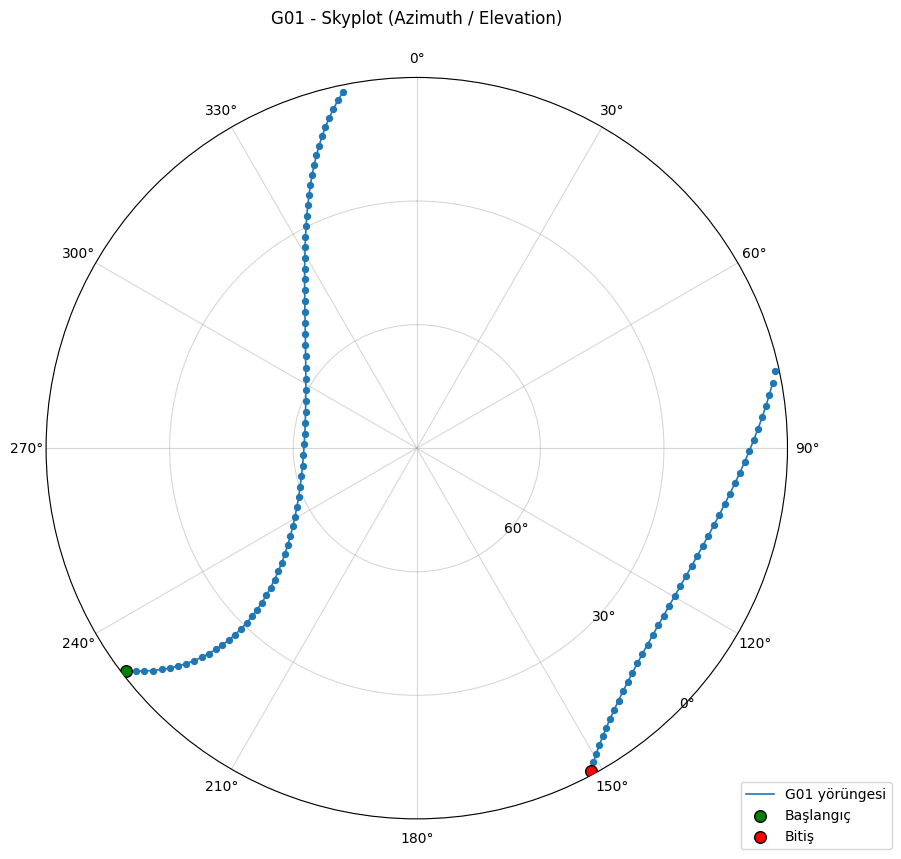

In [11]:
# --- SKYPLOT ---
# Azimuth saat yonunde artar (kuzeyden baslayarak); elevation merkeze dogru artar.
# r = 90 - elevation  →  elevation 90° (zenit) ekranin merkezinde, 0° (ufuk) en disarida.

az_rad = np.deg2rad(sat_df["azimuth"].to_numpy())
r_vals = 90.0 - sat_df["elevation"].to_numpy()

# Uydu battiktan sonra tekrar dogdugunda, ardisik iki epok arasinda
# uzun bir bosluk olusur. Bu bosluklar boyunca cizgi cekilmemesi icin
# epok farki SP3 ornekleme araliginin birkac katini gectiginde NaN
# ekleyerek pas geciyoruz (matplotlib NaN'leri cizmez).
dt = sat_df["epoch"].diff().dt.total_seconds().to_numpy()
typical_step = np.nanmedian(dt[1:]) if len(dt) > 1 else 0.0
gap_threshold = max(typical_step * 1.5, 1.0)  # tipik adimin 1.5 katindan buyukse kopukluk

az_line = az_rad.copy().astype(float)
r_line = r_vals.copy().astype(float)
gap_mask = dt > gap_threshold
az_line[gap_mask] = np.nan
r_line[gap_mask] = np.nan

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="polar")

# Azimuth yonu: 0° kuzeyde, saat yonunde artis
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Azimuth (theta) cizgileri: 30° araliklarla
azimuth_ticks = np.arange(0, 360, 30)
ax.set_thetagrids(
    azimuth_ticks,
    labels=[f"{a}°" for a in azimuth_ticks],
)

# Elevation (radial) cizgileri: 30° araliklarla (0°, 30°, 60°)
# r = 90 - elevation oldugu icin gridler r = 90, 60, 30'da yer alir.
ax.set_ylim(0, 90)
ax.set_rgrids(
    [30, 60, 90],
    labels=["60°", "30°", "0°"],
    angle=135,
)

# Yorunge cizgisi (kopukluklar NaN ile bolunmus) ve nokta isaretleri
ax.plot(az_line, r_line, color="tab:blue", linewidth=1.2,
        label=f"{TARGET_SAT} yörüngesi")
ax.scatter(az_rad, r_vals, color="tab:blue", s=18, zorder=3)
ax.scatter(az_rad[0], r_vals[0], color="green", s=70,
           edgecolor="black", zorder=4, label="Başlangıç")
ax.scatter(az_rad[-1], r_vals[-1], color="red", s=70,
           edgecolor="black", zorder=4, label="Bitiş")

ax.grid(True, alpha=0.5)
ax.set_title(f"{TARGET_SAT} - Skyplot (Azimuth / Elevation)", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.05))

plt.tight_layout()
plt.show()